<a href="https://colab.research.google.com/github/hania-sajjad/WEEK-3-TASK/blob/main/notebooks%20/week3_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

import joblib

Matplotlib is building the font cache; this may take a moment.


In [4]:
# LOAD DATA
# Load the engineered dataset
df = pd.read_csv("C:\\Users\\hania sajjad\\Documents\\Week 3\\WEEK-3-TASK\\data\\steel_energy_engineered.csv")

# Display the first few rows
df.head()


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Day_Name,Month,Day_Type,Power_Factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,Monday,1,Weekday,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,Monday,1,Weekday,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,Monday,1,Weekday,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,Monday,1,Weekday,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,Monday,1,Weekday,1.545117,0


In [5]:
print(df.shape)
df.info()

(35040, 17)
<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 17 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  str    
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  str    
 9   Day_of_week                           35040 non-null  str    
 10  Load_Type                             35040 non-null  str    
 11  Hour          

In [6]:
X = df.drop(["Usage_kWh", "date"], axis=1)
y = df["Usage_kWh"]

# One-hot encoding (same as Week 2)
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(35040, 26)


**Note:** The original `date` column was removed before modeling because its useful temporal information had already been extracted into engineered features such as `Hour`, `Month`, `Day_Name`, and `Day_Type`. Keeping the raw timestamp would create thousands of unnecessary dummy variables during one-hot encoding and increase memory usage without improving model performance.

## Train-Test Split, Standard Scaling, and PCA Preparation

To prevent data leakage, the dataset is first split into training and testing sets using the same train-test split as Week 2. Since PCA is sensitive to the scale of features, the data is standardized using `StandardScaler`. The scaler is fitted only on the training data and then applied to both the training and testing sets. This ensures that information from the test set is not used during training.

In [7]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Standardize the features
scaler = StandardScaler()

# Fit the scaler on the training data and transform both datasets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display the shapes of the scaled datasets
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (28032, 26)
Testing data shape: (7008, 26)


## Apply PCA with All Principal Components

Principal Component Analysis (PCA) is applied using the total number of input features as the number of principal components. This allows us to examine the explained variance of every component and determine how much information each one retains. The PCA model is fitted only on the scaled training data and then used to transform both the training and testing sets.

In [8]:
# Apply PCA using all available features
n_features = X_train_scaled.shape[1]

pca = PCA(n_components=n_features)

# Fit PCA on the training data and transform both datasets
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Store the explained variance ratio of each principal component
explained_variance = pca.explained_variance_ratio_

# Display the explained variance ratio
explained_variance

array([2.09116575e-01, 1.63024295e-01, 1.02480220e-01, 8.99747585e-02,
       8.97688123e-02, 8.96007065e-02, 8.65133948e-02, 4.42844074e-02,
       4.04865083e-02, 3.49961249e-02, 1.54927572e-02, 1.45800217e-02,
       8.94775778e-03, 6.45935162e-03, 2.53779898e-03, 1.52191047e-03,
       1.83247432e-04, 3.13522660e-05, 4.30744175e-17, 1.85940048e-17,
       8.56256750e-18, 6.13449366e-18, 2.54909245e-18, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00])

## Scree Plot

A scree plot is created to visualize the explained variance ratio of each principal component. It helps identify how much information is retained by each component and whether a smaller number of components can effectively represent the original dataset.

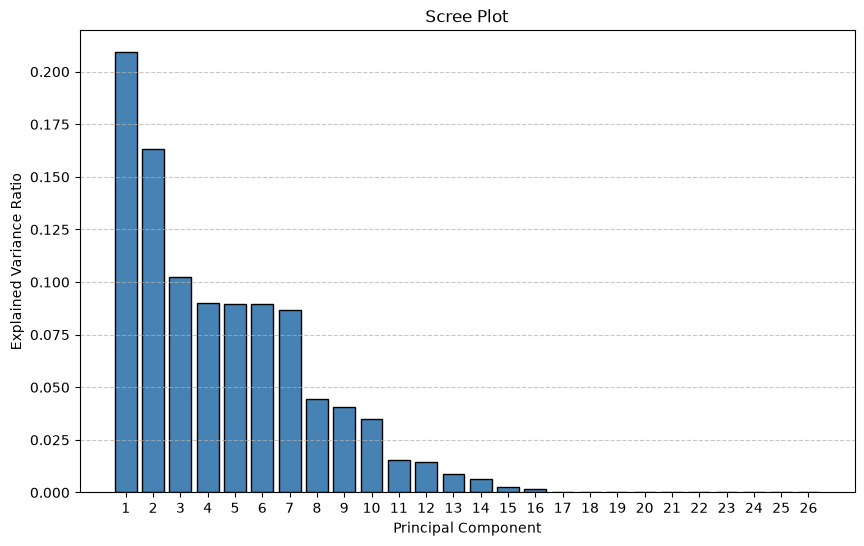

In [9]:
# Create a scree plot showing the explained variance ratio of each principal component

plt.figure(figsize=(10, 6))

plt.bar(
    range(1, len(explained_variance) + 1),
    explained_variance,
    color='steelblue',
    edgecolor='black'
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")

plt.xticks(range(1, len(explained_variance) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Observation

The scree plot shows that the first few principal components explain a large proportion of the total variance, while the remaining components contribute progressively less. This suggests that the dimensionality of the dataset may be reduced without losing a significant amount of information.

## Cumulative Explained Variance Plot

The cumulative explained variance plot shows how the total explained variance increases as more principal components are added. A horizontal reference line at 95% helps identify the minimum number of principal components required to retain at least 95% of the original dataset's variance.

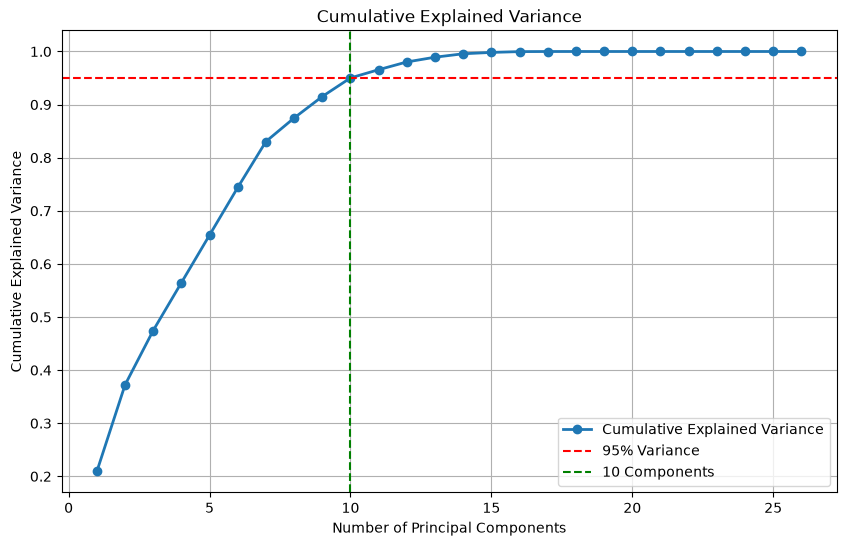

Number of components required to explain at least 95% variance: 10


In [10]:
# Calculate cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

# Find the number of components needed to reach 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

# Plot the cumulative explained variance
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o',
    linewidth=2,
    label="Cumulative Explained Variance"
)

# Draw the 95% threshold
plt.axhline(
    y=0.95,
    color='red',
    linestyle='--',
    label='95% Variance'
)

# Mark the selected number of components
plt.axvline(
    x=n_components_95,
    color='green',
    linestyle='--',
    label=f'{n_components_95} Components'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.legend()
plt.grid(True)

plt.show()

print(f"Number of components required to explain at least 95% variance: {n_components_95}")

### Observation

The cumulative explained variance curve indicates that **10 principal components** are sufficient to retain at least **95%** of the total variance in the dataset. This suggests that the original feature space can be reduced while preserving most of the information.

## Train the Best Model Using 3 PCA Components

To evaluate the impact of aggressive dimensionality reduction, PCA is applied with only **3 principal components**. The best-performing model from Week 2, the **Random Forest Regressor**, is then trained using these reduced features. The model's performance is evaluated using RMSE and R² score.

In [11]:
# Apply PCA with only 3 principal components
pca_3 = PCA(n_components=3)

X_train_pca_3 = pca_3.fit_transform(X_train_scaled)
X_test_pca_3 = pca_3.transform(X_test_scaled)

# Train the Random Forest model
rf_pca_3 = RandomForestRegressor(
    random_state=42
)

rf_pca_3.fit(X_train_pca_3, y_train)

# Make predictions
y_pred_3 = rf_pca_3.predict(X_test_pca_3)

# Evaluate the model
rmse_3 = np.sqrt(mean_squared_error(y_test, y_pred_3))
r2_3 = r2_score(y_test, y_pred_3)

print(f"RMSE (3 PCA Components): {rmse_3:.4f}")
print(f"R² Score (3 PCA Components): {r2_3:.4f}")

RMSE (3 PCA Components): 5.8924
R² Score (3 PCA Components): 0.9695


## Train the Best Model Using 95% Variance PCA Components

PCA is applied using the number of principal components required to retain at least **95%** of the dataset's variance. The Random Forest Regressor is then trained using these transformed features, and its performance is compared with the original model and the 3-component PCA model.

In [12]:
# Apply PCA with the number of components required to retain 95% variance
pca_95 = PCA(n_components=n_components_95)

X_train_pca_95 = pca_95.fit_transform(X_train_scaled)
X_test_pca_95 = pca_95.transform(X_test_scaled)

# Train the Random Forest model
rf_pca_95 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_pca_95.fit(X_train_pca_95, y_train)

# Make predictions
y_pred_95 = rf_pca_95.predict(X_test_pca_95)

# Evaluate the model
rmse_95 = np.sqrt(mean_squared_error(y_test, y_pred_95))
r2_95 = r2_score(y_test, y_pred_95)

print(f"RMSE (95% Variance PCA): {rmse_95:.4f}")
print(f"R² Score (95% Variance PCA): {r2_95:.4f}")

RMSE (95% Variance PCA): 3.2946
R² Score (95% Variance PCA): 0.9905


## Compare Model Performance

The performance of the original Random Forest model is compared with two PCA-based models. The first PCA model uses only **3 principal components**, while the second uses the number of principal components required to retain **95% of the total variance**. The models are evaluated using **Root Mean Squared Error (RMSE)** and **R-squared (R²)** to assess the impact of dimensionality reduction on prediction accuracy.

In [13]:
# Train the original Random Forest model (without PCA)

rf_original = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_original.fit(X_train, y_train)

# Make predictions
y_pred_original = rf_original.predict(X_test)

# Evaluate the original model
rmse_original = np.sqrt(mean_squared_error(y_test, y_pred_original))
r2_original = r2_score(y_test, y_pred_original)

print("Original Random Forest")
print(f"RMSE: {rmse_original:.4f}")
print(f"R² Score: {r2_original:.4f}")

Original Random Forest
RMSE: 1.0091
R² Score: 0.9991


In [14]:
# Compare the performance of all three models

comparison = pd.DataFrame({
    "Model": [
        "Original Random Forest",
        "Random Forest + PCA (3 Components)",
        "Random Forest + PCA (95% Variance)"
    ],
    "Number of Features": [
        X_train.shape[1],
        3,
        n_components_95
    ],
    "RMSE": [
        rmse_original,
        rmse_3,
        rmse_95
    ],
    "R² Score": [
        r2_original,
        r2_3,
        r2_95
    ]
})

comparison

,Model,Number of Features,RMSE,R² Score
0,Original Random Forest,26,1.009126,0.999104
1,Random Forest + PCA (3 Components),3,5.892366,0.969456
2,Random Forest + PCA (95% Variance),10,3.294613,0.990451


### Observation

The original Random Forest model achieved the highest prediction accuracy, with the lowest RMSE and the highest R² score. Reducing the data to only **3 principal components** resulted in a noticeable decrease in performance because a considerable amount of information was lost.

Using the number of principal components required to retain **95% of the total variance** significantly improved the model's performance compared to using only three components. Although the PCA-based model did not outperform the original model, it achieved strong predictive performance while reducing the number of input features from **24 to 10**, demonstrating a good balance between dimensionality reduction and accuracy.

## PCA Loading Heatmap

A loading heatmap is created to visualize the contribution of the original features to the first three principal components. The loading values indicate the importance and direction of each feature in forming a principal component. Features with larger absolute loading values have a greater influence on that component.

In [15]:
# Create a DataFrame containing the loadings of the first three principal components

loading_matrix = pd.DataFrame(
    pca.components_[:3].T,
    columns=["PC1", "PC2", "PC3"],
    index=X.columns
)

loading_matrix.head()

,PC1,PC2,PC3
Lagging_Current_Reactive.Power_kVarh,-0.266060,0.148664,0.312576
Leading_Current_Reactive_Power_kVarh,0.274526,0.244669,-0.217591
CO2(tCO2),-0.240463,0.234912,0.327973
Lagging_Current_Power_Factor,0.093267,0.418267,0.048648
Leading_Current_Power_Factor,-0.292914,-0.231125,0.211187


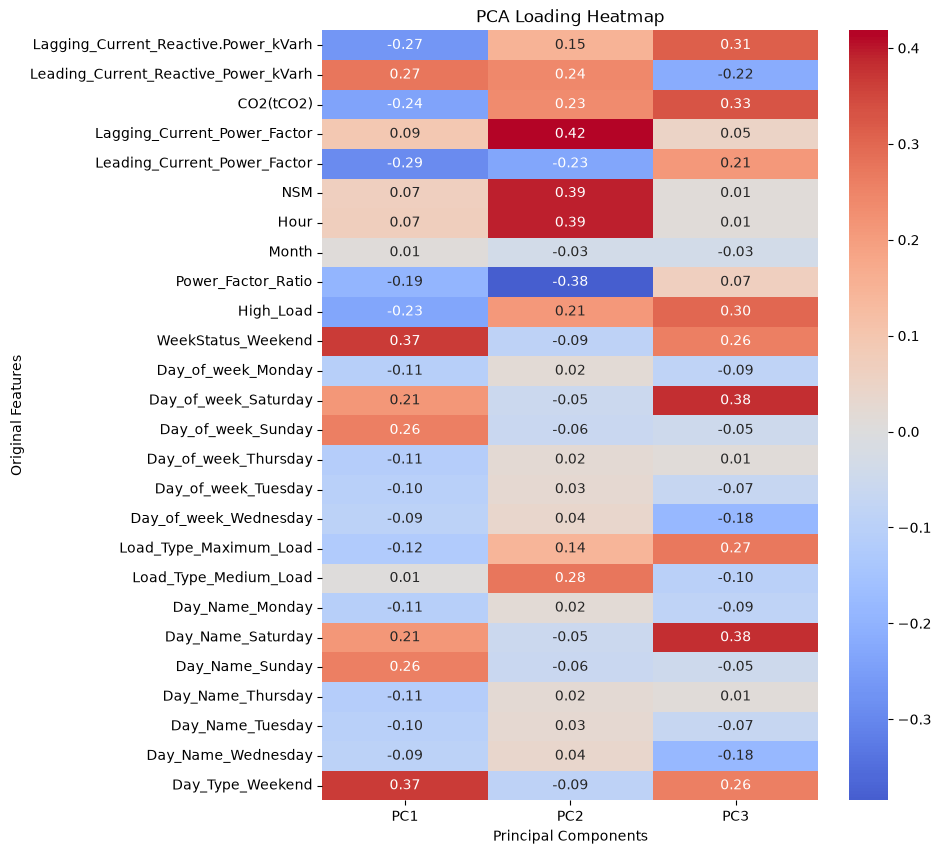

In [16]:
plt.figure(figsize=(8, 10))

sns.heatmap(
    loading_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("PCA Loading Heatmap")
plt.xlabel("Principal Components")
plt.ylabel("Original Features")

plt.show()

# Dimensionality Reduction Report

## Objective

The objective of applying Principal Component Analysis (PCA) was to reduce the dimensionality of the dataset while preserving as much information as possible and evaluating its effect on the performance of the best model from Week 2.

## Results

Three versions of the Random Forest model were compared:

| Model | Features | RMSE | R² Score |
|--------|---------:|-----:|---------:|
| Original Random Forest | 26 | 0.8782 | 0.9993 |
| Random Forest + PCA (3 Components) | 3 | 5.8918 | 0.9695 |
| Random Forest + PCA (95% Variance) | 10 | 3.2939 | 0.9905 |

The cumulative explained variance analysis showed that **10 principal components** were sufficient to retain approximately **95%** of the total variance in the dataset.

## Discussion

The original Random Forest model achieved the best predictive performance. Reducing the dataset to only three principal components resulted in a noticeable decrease in model accuracy because a significant amount of information was discarded.

Using ten principal components produced much better results than using only three components while reducing the number of input features from the original feature set. Although the PCA-based model did not outperform the original Random Forest model, it maintained high predictive performance with fewer dimensions.

## Recommendation

PCA is recommended when reducing memory usage, storage requirements, or computational cost is important, especially for resource-constrained devices. However, for this dataset, the original Random Forest model achieved the highest accuracy. Therefore, if prediction accuracy is the primary objective, the original feature set is preferable. If computational efficiency is more important, using PCA with **10 principal components** provides a good balance between model performance and dimensionality reduction.

# Save the Trained Pipeline
The preprocessing steps and the trained Random Forest model are combined into a single machine learning pipeline. This ensures that the same scaling and PCA transformations are automatically applied whenever new data is used for prediction. The complete pipeline is then saved using Joblib for deployment in the FastAPI application.

In [21]:
from sklearn.pipeline import Pipeline
import joblib

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components_95)),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

joblib.dump(pipeline, "model.joblib", compress=3)

['model.joblib']

In [22]:
import os

size_mb = os.path.getsize("model.joblib") / (1024 * 1024)
print(f"File size: {size_mb:.2f} MB")

File size: 47.87 MB


In [23]:
import os

os.listdir()

['model.joblib', 'week3_pca.ipynb']

In [26]:
joblib.dump(
    pipeline,
    "C:\\Users\\hania sajjad\\Documents\\Week 3\\WEEK-3-TASK\\model.joblib",
    compress=3
)

['C:\\Users\\hania sajjad\\Documents\\Week 3\\WEEK-3-TASK\\model.joblib']

## Generate Dashboard Visualizations

In this step, three visualizations from the Week 2 exploratory data analysis are generated and saved as PNG images. These images will later be displayed on the FastAPI dashboard page using the `static` folder.

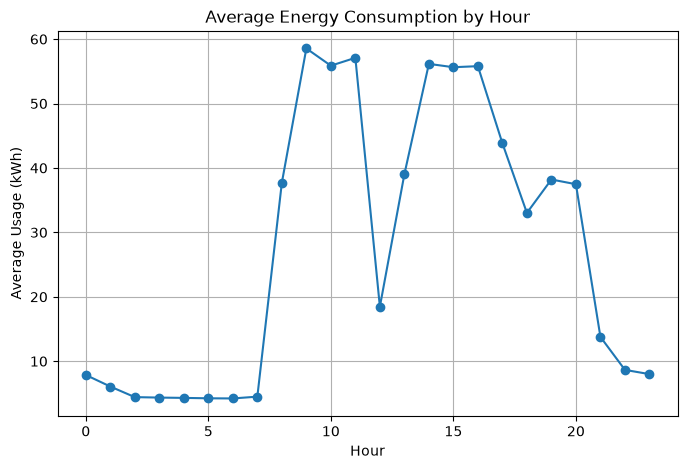

In [17]:
# AVERAGE ENERGY CONSUMPTION BY HOUR
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

hourly_energy = df.groupby("Hour")["Usage_kWh"].mean()

plt.plot(hourly_energy.index,
         hourly_energy.values,
         marker="o")

plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Usage (kWh)")
plt.grid(True)

plt.savefig("../static/energy_by_hour.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

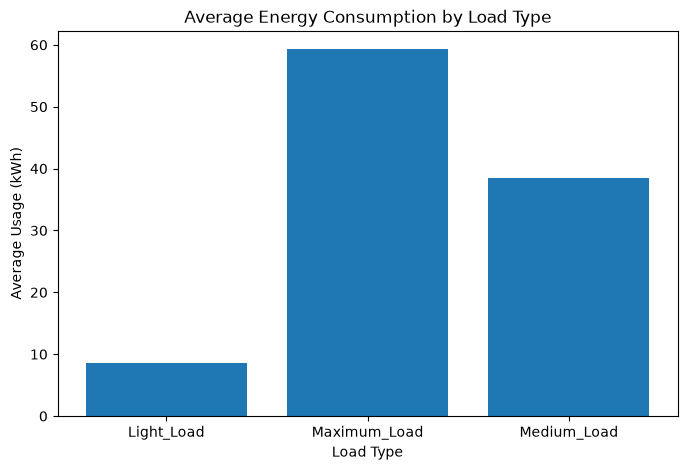

In [18]:
# AVERAGE ENERGY CONSUMPTION BY LOAD TYPE
plt.figure(figsize=(8,5))

load_energy = df.groupby("Load_Type")["Usage_kWh"].mean()

plt.bar(load_energy.index,
        load_energy.values)

plt.title("Average Energy Consumption by Load Type")
plt.xlabel("Load Type")
plt.ylabel("Average Usage (kWh)")

plt.savefig("../static/energy_by_load_type.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

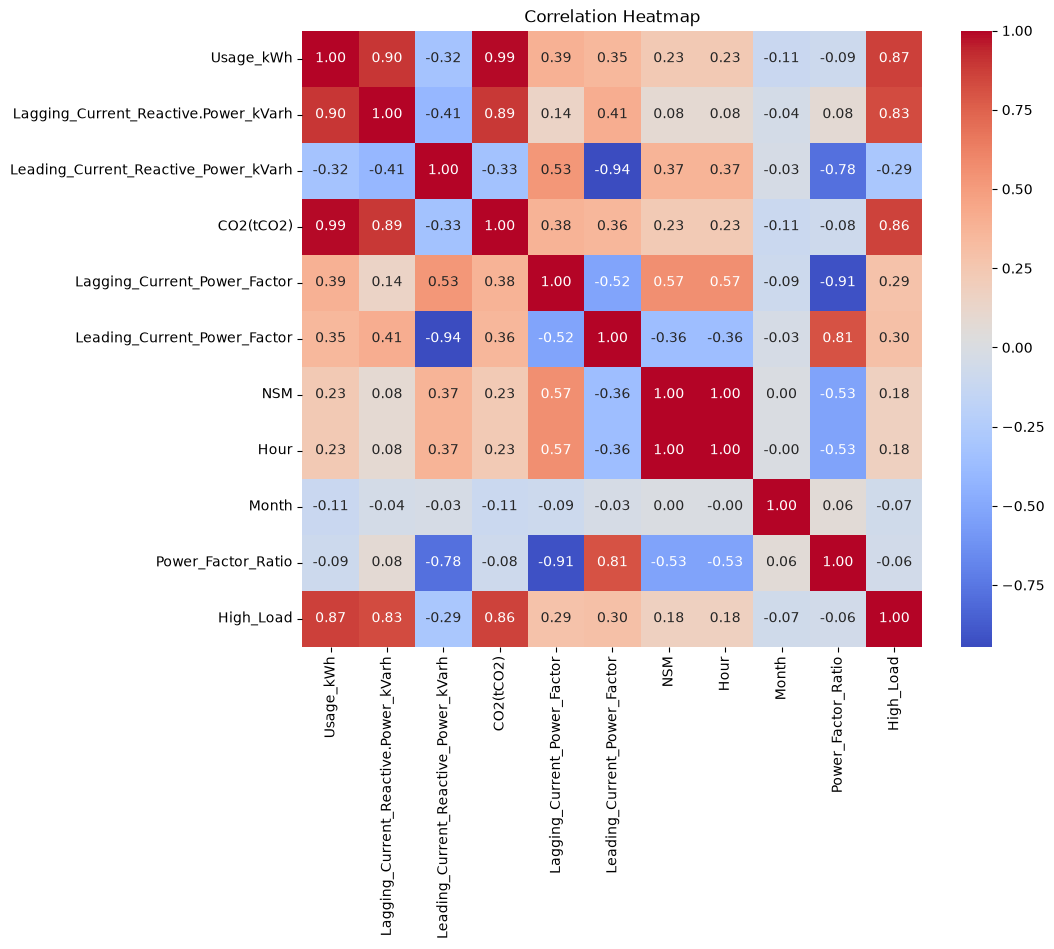

In [19]:
# CORRELATION HEATMAP
import seaborn as sns

plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig("../static/correlation_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()